In [1]:
import os
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from sklearn.linear_model import LinearRegression
import json
import numpy as np
import torch
import torch.nn as nn
import copy
import time

# Models generated by random sampling

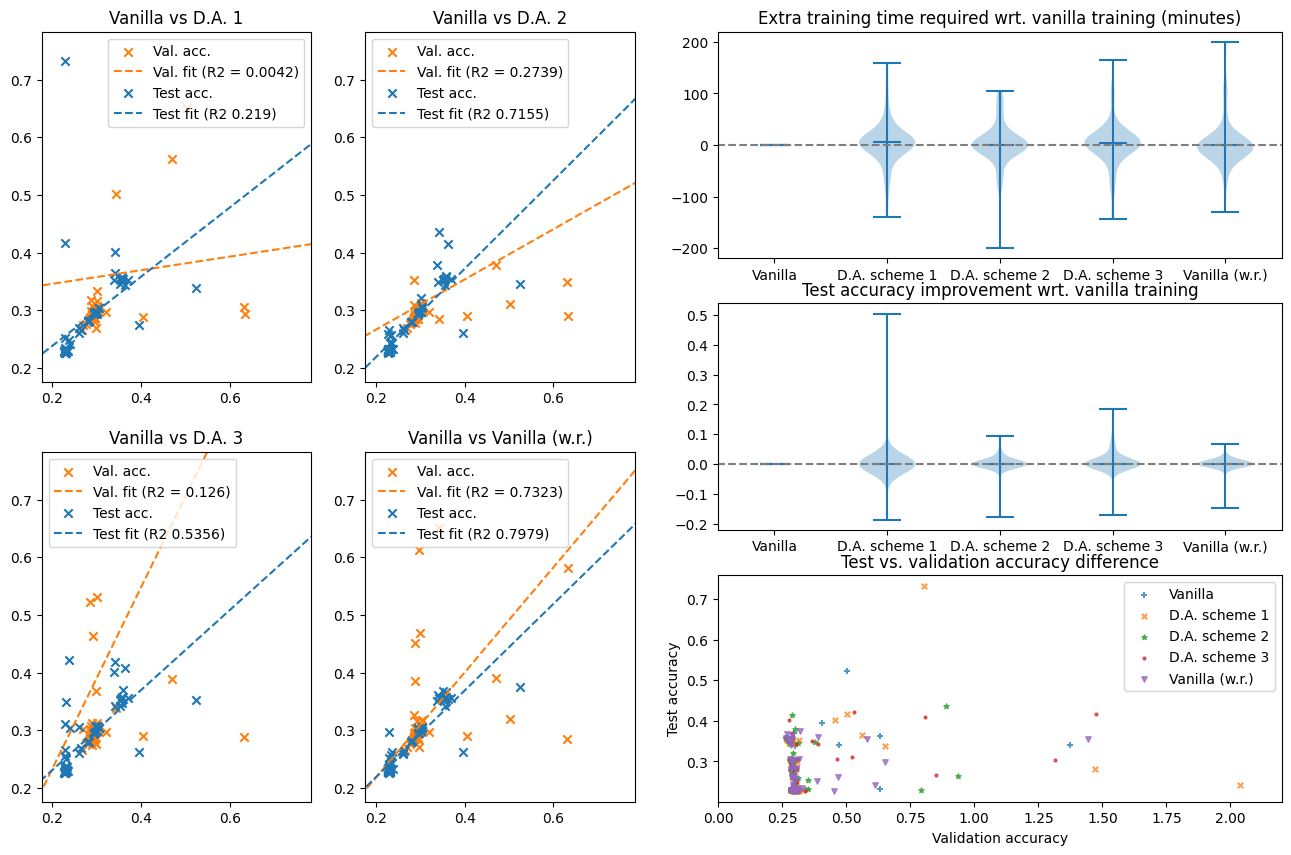

In [2]:
# Load results
if os.path.exists('tr_accs.json'):
    with open('tr_accs.json', 'r') as file:
        tr_accs = json.load(file)
    with open('val_accs.json', 'r') as file:
        val_accs = json.load(file)
    with open('test_accs.json', 'r') as file:
        test_accs = json.load(file)
    with open('train_times.json', 'r') as file:
        train_times = json.load(file)

# Create numpy arrays
test_van = np.array([test for test in test_accs["vanilla"] if test != None])
test_da1 = np.array([test for test in test_accs["daug1"] if test != None])
test_da2 = np.array([test for test in test_accs["daug2"] if test != None])
test_da3 = np.array([test for test in test_accs["daug3"] if test != None])
test_rew = np.array([test for test in test_accs["reinit"] if test != None])
val_van = np.array([val for val in val_accs["vanilla"] if val != None])
val_da1 = np.array([val for val in val_accs["daug1"] if val != None])
val_da2 = np.array([val for val in val_accs["daug2"] if val != None])
val_da3 = np.array([val for val in val_accs["daug3"] if val != None])
val_rew = np.array([val for val in val_accs["reinit"] if val != None])
times_van = np.array([time for time in train_times["vanilla"] if time != None])
times_da1 = np.array([time for time in train_times["daug1"] if time != None])
times_da2 = np.array([time for time in train_times["daug2"] if time != None])
times_da3 = np.array([time for time in train_times["daug3"] if time != None])
times_rew = np.array([time for time in train_times["reinit"] if time != None])

treshold = 1
valid = (test_van<treshold)*(test_da1<treshold)*(test_da2<treshold)*(test_da3<treshold)*(test_rew<treshold)
test_van = test_van[valid]
test_da1 = test_da1[valid]
test_da2 = test_da2[valid]
test_da3 = test_da3[valid]
test_rew = test_rew[valid]
val_van = val_van[valid]
val_da1 = val_da1[valid]
val_da2 = val_da2[valid]
val_da3 = val_da3[valid]
val_rew = val_rew[valid]

# Check correlation between attained accuracies in validation
reg1_val = LinearRegression().fit(val_van.reshape(-1, 1),val_da1.reshape(-1, 1))
R2_1_val = round(reg1_val.score(val_van.reshape(-1, 1),val_da1.reshape(-1, 1)), 4)
reg2_val = LinearRegression().fit(val_van.reshape(-1, 1),val_da2.reshape(-1, 1))
R2_2_val = round(reg2_val.score(val_van.reshape(-1, 1),val_da2.reshape(-1, 1)), 4)
reg3_val = LinearRegression().fit(val_van.reshape(-1, 1),val_da3.reshape(-1, 1))
R2_3_val = round(reg3_val.score(val_van.reshape(-1, 1),val_da3.reshape(-1, 1)), 4)
reg4_val = LinearRegression().fit(val_van.reshape(-1, 1),val_rew.reshape(-1, 1))
R2_4_val = round(reg4_val.score(val_van.reshape(-1, 1),val_rew.reshape(-1, 1)), 4)
# Check correlation between attained accuracies in test
reg1 = LinearRegression().fit(test_van.reshape(-1, 1),test_da1.reshape(-1, 1))
R2_1 = round(reg1.score(test_van.reshape(-1, 1),test_da1.reshape(-1, 1)), 4)
reg2 = LinearRegression().fit(test_van.reshape(-1, 1),test_da2.reshape(-1, 1))
R2_2 = round(reg2.score(test_van.reshape(-1, 1),test_da2.reshape(-1, 1)), 4)
reg3 = LinearRegression().fit(test_van.reshape(-1, 1),test_da3.reshape(-1, 1))
R2_3 = round(reg3.score(test_van.reshape(-1, 1),test_da3.reshape(-1, 1)), 4)
reg4 = LinearRegression().fit(test_van.reshape(-1, 1),test_rew.reshape(-1, 1))
R2_4 = round(reg4.score(test_van.reshape(-1, 1),test_rew.reshape(-1, 1)), 4)

# Calculate train time and performance differences model-wise to plot them later
diff1 = []
diff2 = []
diff3 = []
diff4 = []
for i, t in enumerate(test_van):
    diff1 += [test_da1[i]-t]
    diff2 += [test_da2[i]-t]
    diff3 += [test_da3[i]-t]
    diff4 += [test_rew[i]-t]
difft1 = []
difft2 = []
difft3 = []
difft4 = []
for i, t in enumerate(times_van):
    difft1 += [times_da1[i]-t]
    difft2 += [times_da2[i]-t]
    difft3 += [times_da3[i]-t]
    difft4 += [times_rew[i]-t]
    
plt.figure(figsize = (16,10))
lims = [np.min(np.concatenate((test_van,test_da1,test_da2,test_da3,test_rew)))-0.05, np.min([1, np.max(np.concatenate((test_van,test_da1,test_da2,test_da3,test_rew)))+0.05])]

plt.subplot(241)
#plt.plot([0,1],[0,1], c="silver")
plt.scatter(val_van, val_da1, marker = "x", c = "tab:orange")
plt.plot([0,1],[reg1_val.intercept_[0], reg1_val.intercept_[0]+reg1_val.coef_[0][0]], "--", c="tab:orange")
plt.scatter(test_van, test_da1, marker = "x", c = "tab:blue")
plt.plot([0,1],[reg1.intercept_[0], reg1.intercept_[0]+reg1.coef_[0][0]], "--", c="tab:blue")
#plt.scatter(val_van, val_da1, c = "tab:orange")
plt.legend(["Val. acc.", "Val. fit (R2 = "+str(R2_1_val)+")", "Test acc.", "Test fit (R2 "+str(R2_1)+")"])
plt.title("Vanilla vs D.A. 1")
plt.xlim(lims)
plt.ylim(lims)

plt.subplot(242)
#plt.plot([0,1],[0,1], c="silver")
plt.scatter(val_van, val_da2, marker = "x", c = "tab:orange")
plt.plot([0,1],[reg2_val.intercept_[0], reg2_val.intercept_[0]+reg2_val.coef_[0][0]], "--", c="tab:orange")
plt.scatter(test_van, test_da2, marker = "x", c = "tab:blue")
plt.plot([0,1],[reg2.intercept_[0], reg2.intercept_[0]+reg2.coef_[0][0]], "--", c="tab:blue")
#plt.scatter(val_van, val_da2, c = "tab:orange")
plt.legend(["Val. acc.", "Val. fit (R2 = "+str(R2_2_val)+")", "Test acc.", "Test fit (R2 "+str(R2_2)+")"])
plt.title("Vanilla vs D.A. 2")
plt.xlim(lims)
plt.ylim(lims)

plt.subplot(245)
#plt.plot([0,1],[0,1], c="silver")
plt.scatter(val_van, val_da3, marker = "x", c = "tab:orange")
plt.plot([0,1],[reg3_val.intercept_[0], reg3_val.intercept_[0]+reg3_val.coef_[0][0]], "--", c="tab:orange")
plt.scatter(test_van, test_da3, marker = "x", c = "tab:blue")
plt.plot([0,1],[reg3.intercept_[0], reg3.intercept_[0]+reg3.coef_[0][0]], "--", c="tab:blue")
#plt.scatter(val_van, val_da3, c = "tab:orange")
plt.legend(["Val. acc.", "Val. fit (R2 = "+str(R2_3_val)+")", "Test acc.", "Test fit (R2 "+str(R2_3)+")"])
plt.title("Vanilla vs D.A. 3")
plt.xlim(lims)
plt.ylim(lims)

plt.subplot(246)
#plt.plot([0,1],[0,1], c="silver")
#plt.scatter(val_van, val_rew, c = "tab:orange")
plt.scatter(val_van, val_rew, marker = "x", c = "tab:orange")
plt.plot([0,1],[reg4_val.intercept_[0], reg4_val.intercept_[0]+reg4_val.coef_[0][0]], "--", c="tab:orange")
plt.scatter(test_van, test_rew, marker = "x", c = "tab:blue")
plt.plot([0,1],[reg4.intercept_[0], reg4.intercept_[0]+reg4.coef_[0][0]], "--", c="tab:blue")
plt.legend(["Val. acc.", "Val. fit (R2 = "+str(R2_4_val)+")", "Test acc.", "Test fit (R2 "+str(R2_4)+")"])
plt.title("Vanilla vs Vanilla (w.r.)")
plt.xlim(lims)
plt.ylim(lims)

plt.subplot(322)
plt.violinplot([[0], [d/60 for d in difft1], [d/60 for d in difft2], [d/60 for d in difft3], [d/60 for d in difft4]], showmedians = True)
plt.gca().set_xticks([1,2,3,4,5])
plt.gca().set_xticklabels(["Vanilla", "D.A. scheme 1", "D.A. scheme 2", "D.A. scheme 3", "Vanilla (w.r.)"])
plt.plot([0,6],[0,0], "--", c = "tab:gray")
plt.xlim([0.5, 5.5])
plt.title("Extra training time required wrt. vanilla training (minutes)")

plt.subplot(324)
plt.violinplot([[0], diff1, diff2, diff3, diff4], showmedians = True)
plt.gca().set_xticks([1,2,3,4,5])
plt.gca().set_xticklabels(["Vanilla", "D.A. scheme 1", "D.A. scheme 2", "D.A. scheme 3", "Vanilla (w.r.)"])
plt.plot([0,6],[0,0], "--", c = "tab:gray")
plt.xlim([0.5, 5.5])
plt.title("Test accuracy improvement wrt. vanilla training")


#plt.subplot(326)
#plt.violinplot([[test_van[i]-acc for i, acc in enumerate(val_van)], [test_da1[i]-acc for i, acc in enumerate(val_da1)], [test_da2[i]-acc for i, acc in enumerate(val_da2)], [test_da3[i]-acc for i, acc in enumerate(val_da3)], [test_rew[i]-acc for i, acc in enumerate(val_rew)]], showmedians = True)
#plt.gca().set_xticks([1,2,3,4,5])
#plt.gca().set_xticklabels(["Vanilla", "D.A. scheme 1", "D.A. scheme 2", "D.A. scheme 3", "Vanilla (w.r.)"])
#plt.plot([0,6],[0,0], "--", c = "tab:gray")
#plt.xlim([0.5, 5.5])
#plt.title("Test - validation accuracy difference")

plt.subplot(326)
plt.scatter(np.sort(val_van), test_van[np.argsort(val_van)], marker = "+", alpha=0.75, s = 15)
plt.scatter(np.sort(val_da1), test_da1[np.argsort(val_da1)], marker = "x", alpha=0.75, s = 15)
plt.scatter(np.sort(val_da2), test_da2[np.argsort(val_da2)], marker = "*", alpha=0.75, s = 15)
plt.scatter(np.sort(val_da3), test_da3[np.argsort(val_da3)], marker = ".", alpha=0.75, s = 15)
plt.scatter(np.sort(val_rew), test_rew[np.argsort(val_rew)], marker = "v", alpha=0.75, s = 15)
plt.xlim((0,2.2))
plt.gca().set_xlabel("Validation accuracy")
plt.gca().set_ylabel("Test accuracy")
plt.legend(["Vanilla", "D.A. scheme 1", "D.A. scheme 2", "D.A. scheme 3", "Vanilla (w.r.)"])
plt.title("Test vs. validation accuracy difference")

plt.savefig("callibration_data_aug_random.svg")
plt.show()

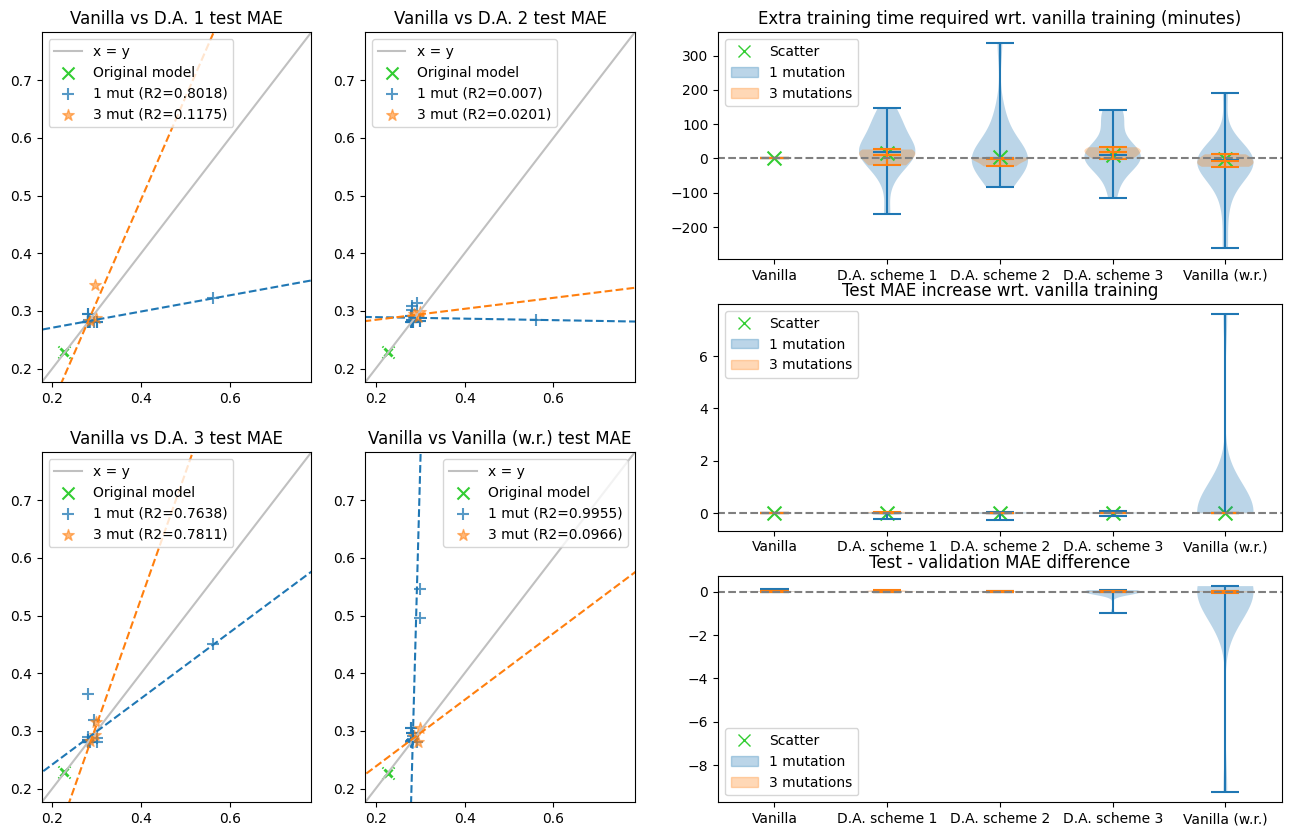

In [8]:
# Load results
if os.path.exists('tr_accs_original.json'):
    original_model_stats = {}
    with open('tr_accs_original.json', 'r') as file:
        tr_accs_original = json.load(file)
        original_model_stats["train"] = list(tr_accs_original.values())
    with open('val_accs_original.json', 'r') as file:
        val_accs_original = json.load(file)
        original_model_stats["val"] = list(val_accs_original.values())
    with open('test_accs_original.json', 'r') as file:
        test_accs_original = json.load(file)
        original_model_stats["test"] = [t[0] for t in list(test_accs_original.values())]
    with open('train_times_original.json', 'r') as file:
        train_times_original = json.load(file)
        original_model_stats["times"] = [t[0] for t in list(train_times_original.values())]

if os.path.exists('tr_accs_1mut.json'):
    with open('tr_accs_1mut.json', 'r') as file:
        tr_accs_1mut = json.load(file)
    with open('val_accs_1mut.json', 'r') as file:
        val_accs_1mut = json.load(file)
    with open('test_accs_1mut.json', 'r') as file:
        test_accs_1mut = json.load(file)
    with open('train_times_1mut.json', 'r') as file:
        train_times_1mut = json.load(file)

if os.path.exists('tr_accs_3mut.json'):
    with open('tr_accs_3mut.json', 'r') as file:
        tr_accs_3mut = json.load(file)
    with open('val_accs_3mut.json', 'r') as file:
        val_accs_3mut = json.load(file)
    with open('test_accs_3mut.json', 'r') as file:
        test_accs_3mut = json.load(file)
    with open('train_times_3mut.json', 'r') as file:
        train_times_3mut = json.load(file)

# Create np arrays
test_van_1mut = np.array([test for test in test_accs_1mut["vanilla"] if test != None])
test_da1_1mut = np.array([test for test in test_accs_1mut["daug1"] if test != None])
test_da2_1mut = np.array([test for test in test_accs_1mut["daug2"] if test != None])
test_da3_1mut = np.array([test for test in test_accs_1mut["daug3"] if test != None])
test_rew_1mut = np.array([test for test in test_accs_1mut["reinit"] if test != None])
val_van_1mut = np.array([val for val in val_accs_1mut["vanilla"] if val != None])
val_da1_1mut = np.array([val for val in val_accs_1mut["daug1"] if val != None])
val_da2_1mut = np.array([val for val in val_accs_1mut["daug2"] if val != None])
val_da3_1mut = np.array([val for val in val_accs_1mut["daug3"] if val != None])
val_rew_1mut = np.array([val for val in val_accs_1mut["reinit"] if val != None])
times_van_1mut = np.array([time for time in train_times_1mut["vanilla"] if time != None])
times_da1_1mut = np.array([time for time in train_times_1mut["daug1"] if time != None])
times_da2_1mut = np.array([time for time in train_times_1mut["daug2"] if time != None])
times_da3_1mut = np.array([time for time in train_times_1mut["daug3"] if time != None])
times_rew_1mut = np.array([time for time in train_times_1mut["reinit"] if time != None])

test_van_3mut = np.array([test for test in test_accs_3mut["vanilla"] if test != None])
test_da1_3mut = np.array([test for test in test_accs_3mut["daug1"] if test != None])
test_da2_3mut = np.array([test for test in test_accs_3mut["daug2"] if test != None])
test_da3_3mut = np.array([test for test in test_accs_3mut["daug3"] if test != None])
test_rew_3mut = np.array([test for test in test_accs_3mut["reinit"] if test != None])
val_van_3mut = np.array([val for val in val_accs_3mut["vanilla"] if val != None])
val_da1_3mut = np.array([val for val in val_accs_3mut["daug1"] if val != None])
val_da2_3mut = np.array([val for val in val_accs_3mut["daug2"] if val != None])
val_da3_3mut = np.array([val for val in val_accs_3mut["daug3"] if val != None])
val_rew_3mut = np.array([val for val in val_accs_3mut["reinit"] if val != None])
times_van_3mut = np.array([time for time in train_times_3mut["vanilla"] if time != None])
times_da1_3mut = np.array([time for time in train_times_3mut["daug1"] if time != None])
times_da2_3mut = np.array([time for time in train_times_3mut["daug2"] if time != None])
times_da3_3mut = np.array([time for time in train_times_3mut["daug3"] if time != None])
times_rew_3mut = np.array([time for time in train_times_3mut["reinit"] if time != None])


# Check correlation between attained accuracies in test
reg1_1 = LinearRegression().fit(test_van_1mut.reshape(-1, 1),test_da1_1mut.reshape(-1, 1))
R2_1_1 = round(reg1_1.score(test_van_1mut.reshape(-1, 1),test_da1_1mut.reshape(-1, 1)), 4)
reg2_1 = LinearRegression().fit(test_van_1mut.reshape(-1, 1),test_da2_1mut.reshape(-1, 1))
R2_2_1 = round(reg2_1.score(test_van_1mut.reshape(-1, 1),test_da2_1mut.reshape(-1, 1)), 4)
reg3_1 = LinearRegression().fit(test_van_1mut.reshape(-1, 1),test_da3_1mut.reshape(-1, 1))
R2_3_1 = round(reg3_1.score(test_van_1mut.reshape(-1, 1),test_da3_1mut.reshape(-1, 1)), 4)
reg4_1 = LinearRegression().fit(test_van_1mut.reshape(-1, 1),test_rew_1mut.reshape(-1, 1))
R2_4_1 = round(reg4_1.score(test_van_1mut.reshape(-1, 1),test_rew_1mut.reshape(-1, 1)), 4)

reg1_3 = LinearRegression().fit(test_van_3mut.reshape(-1, 1),test_da1_3mut.reshape(-1, 1))
R2_1_3 = round(reg1_3.score(test_van_3mut.reshape(-1, 1),test_da1_3mut.reshape(-1, 1)), 4)
reg2_3 = LinearRegression().fit(test_van_3mut.reshape(-1, 1),test_da2_3mut.reshape(-1, 1))
R2_2_3 = round(reg2_3.score(test_van_3mut.reshape(-1, 1),test_da2_3mut.reshape(-1, 1)), 4)
reg3_3 = LinearRegression().fit(test_van_3mut.reshape(-1, 1),test_da3_3mut.reshape(-1, 1))
R2_3_3 = round(reg3_3.score(test_van_3mut.reshape(-1, 1),test_da3_3mut.reshape(-1, 1)), 4)
reg4_3 = LinearRegression().fit(test_van_3mut.reshape(-1, 1),test_rew_3mut.reshape(-1, 1))
R2_4_3 = round(reg4_3.score(test_van_3mut.reshape(-1, 1),test_rew_3mut.reshape(-1, 1)), 4)


# Calculate train time and performance differences model-wise to plot them later
diff1_1mut = []
diff2_1mut = []
diff3_1mut = []
diff4_1mut = []
for i, t in enumerate(test_van_1mut):
    diff1_1mut += [test_da1_1mut[i]-t]
    diff2_1mut += [test_da2_1mut[i]-t]
    diff3_1mut += [test_da3_1mut[i]-t]
    diff4_1mut += [test_rew_1mut[i]-t]
difft1_1mut = []
difft2_1mut = []
difft3_1mut = []
difft4_1mut = []
for i, t in enumerate(times_van_1mut):
    difft1_1mut += [times_da1_1mut[i]-t]
    difft2_1mut += [times_da2_1mut[i]-t]
    difft3_1mut += [times_da3_1mut[i]-t]
    difft4_1mut += [times_rew_1mut[i]-t]

diff1_3mut = []
diff2_3mut = []
diff3_3mut = []
diff4_3mut = []
for i, t in enumerate(test_van_3mut):
    diff1_3mut += [test_da1_3mut[i]-t]
    diff2_3mut += [test_da2_3mut[i]-t]
    diff3_3mut += [test_da3_3mut[i]-t]
    diff4_3mut += [test_rew_3mut[i]-t]
difft1_3mut = []
difft2_3mut = []
difft3_3mut = []
difft4_3mut = []
for i, t in enumerate(times_van_3mut):
    difft1_3mut += [times_da1_3mut[i]-t]
    difft2_3mut += [times_da2_3mut[i]-t]
    difft3_3mut += [times_da3_3mut[i]-t]
    difft4_3mut += [times_rew_3mut[i]-t]

plt.figure(figsize = (16,10))
#lims = [np.min(np.concatenate((test_van_1mut,test_da1_1mut,test_da1_3mut,test_da2_1mut,test_da2_3mut,test_da3_1mut,test_da3_3mut,test_rew_1mut,test_rew_3mut)))-0.05, np.min([1, np.max(np.concatenate((test_van_1mut,test_da1_1mut,test_da1_3mut,test_da2_1mut,test_da2_3mut,test_da3_1mut,test_da3_3mut,test_rew_1mut,test_rew_3mut)))+0.05])]

plt.subplot(241)
plt.plot([0,1],[0,1], c="silver")
plt.scatter([original_model_stats["test"][0]], [original_model_stats["test"][1]], s = 75, marker = "x", c = "limegreen")
plt.scatter(test_van_1mut, test_da1_1mut, marker = "+", c = "tab:blue", alpha=0.75, s = 75)
plt.scatter(test_van_3mut, test_da1_3mut, marker = "*", c = "tab:orange", alpha=0.55, s = 75)
plt.plot([0,1],[reg1_1.intercept_[0], reg1_1.intercept_[0]+reg1_1.coef_[0][0]], "--", c="tab:blue")
plt.plot([0,1],[reg1_3.intercept_[0], reg1_3.intercept_[0]+reg1_3.coef_[0][0]], "--", c="tab:orange")
plt.legend(["x = y", "Original model", "1 mut (R2="+str(R2_1_1)+")", "3 mut (R2="+str(R2_1_3)+")"])
plt.scatter([original_model_stats["test"][0]], [original_model_stats["test"][1]], s = 75, marker = "X", c = "limegreen", edgecolors = "w")
plt.title("Vanilla vs D.A. 1 test MAE")
plt.xlim(lims)
plt.ylim(lims)

plt.subplot(242)
plt.plot([0,1],[0,1], c="silver")
plt.scatter([original_model_stats["test"][0]], [original_model_stats["test"][2]], s = 75, marker = "x", c = "limegreen")
plt.scatter(test_van_1mut, test_da2_1mut, marker = "+", c = "tab:blue", alpha=0.75, s = 75)
plt.scatter(test_van_3mut, test_da2_3mut, marker = "*", c = "tab:orange", alpha=0.55, s = 75)
plt.plot([0,1],[reg2_1.intercept_[0], reg2_1.intercept_[0]+reg2_1.coef_[0][0]], "--", c="tab:blue")
plt.plot([0,1],[reg2_3.intercept_[0], reg2_3.intercept_[0]+reg2_3.coef_[0][0]], "--", c="tab:orange")
plt.legend(["x = y", "Original model", "1 mut (R2="+str(R2_2_1)+")", "3 mut (R2="+str(R2_2_3)+")"])
plt.scatter([original_model_stats["test"][0]], [original_model_stats["test"][2]], s = 75, marker = "X", c = "limegreen", edgecolors = "w")
plt.title("Vanilla vs D.A. 2 test MAE")
plt.xlim(lims)
plt.ylim(lims)

plt.subplot(245)
plt.plot([0,1],[0,1], c="silver")
plt.scatter([original_model_stats["test"][0]], [original_model_stats["test"][3]], s = 75, marker = "x", c = "limegreen")
plt.scatter(test_van_1mut, test_da3_1mut, marker = "+", c = "tab:blue", alpha=0.75, s = 75)
plt.scatter(test_van_3mut, test_da3_3mut, marker = "*", c = "tab:orange", alpha=0.55, s = 75)
plt.plot([0,1],[reg3_1.intercept_[0], reg3_1.intercept_[0]+reg3_1.coef_[0][0]], "--", c="tab:blue")
plt.plot([0,1],[reg3_3.intercept_[0], reg3_3.intercept_[0]+reg3_3.coef_[0][0]], "--", c="tab:orange")
plt.legend(["x = y", "Original model", "1 mut (R2="+str(R2_3_1)+")", "3 mut (R2="+str(R2_3_3)+")"])
plt.scatter([original_model_stats["test"][0]], [original_model_stats["test"][3]], s = 75, marker = "X", c = "limegreen", edgecolors = "w")
plt.title("Vanilla vs D.A. 3 test MAE")
plt.xlim(lims)
plt.ylim(lims)

plt.subplot(246)
plt.plot([0,1],[0,1], c="silver")
plt.scatter([original_model_stats["test"][0]], [original_model_stats["test"][4]], s = 75, marker = "x", c = "limegreen")
plt.scatter(test_van_1mut, test_rew_1mut, marker = "+", c = "tab:blue", alpha=0.75, s = 75)
plt.scatter(test_van_3mut, test_rew_3mut, marker = "*", c = "tab:orange", alpha=0.55, s = 75)
plt.plot([0,1],[reg4_1.intercept_[0], reg4_1.intercept_[0]+reg4_1.coef_[0][0]], "--", c="tab:blue")
plt.plot([0,1],[reg4_3.intercept_[0], reg4_3.intercept_[0]+reg4_3.coef_[0][0]], "--", c="tab:orange")
plt.legend(["x = y", "Original model", "1 mut (R2="+str(R2_4_1)+")", "3 mut (R2="+str(R2_4_3)+")"])
plt.scatter([original_model_stats["test"][0]], [original_model_stats["test"][4]], s = 75, marker = "X", c = "limegreen", edgecolors = "w")
plt.title("Vanilla vs Vanilla (w.r.) test MAE")
plt.xlim(lims)
plt.ylim(lims)

labels = []
plt.subplot(322)
vlp1 = plt.violinplot([[0], [d/60 for d in difft1_1mut], [d/60 for d in difft2_1mut], [d/60 for d in difft3_1mut], [d/60 for d in difft4_1mut]], showmedians = True)
color1 = vlp1["bodies"][0].get_facecolor().flatten()
vlp2 = plt.violinplot([[0], [d/60 for d in difft1_3mut], [d/60 for d in difft2_3mut], [d/60 for d in difft3_3mut], [d/60 for d in difft4_3mut]], showmedians = True)
color2 = vlp2["bodies"][0].get_facecolor().flatten()
scp = plt.scatter([1, 2, 3, 4, 5], [0, (original_model_stats["times"][1]-original_model_stats["times"][0])/60, (original_model_stats["times"][2]-original_model_stats["times"][0])/60, (original_model_stats["times"][3]-original_model_stats["times"][0])/60, (original_model_stats["times"][4]-original_model_stats["times"][0])/60], s = 100, marker = "x", c = "limegreen")

labels.append((Line2D([0], [0], marker='x', color='limegreen', markersize=8.5, linestyle='None'), 'Scatter'))
labels.append((mpatches.Patch(color=color1), "1 mutation"))
labels.append((mpatches.Patch(color=color2), "3 mutations"))
plt.gca().set_xticks([1,2,3,4,5])
plt.gca().set_xticklabels(["Vanilla", "D.A. scheme 1", "D.A. scheme 2", "D.A. scheme 3", "Vanilla (w.r.)"])
plt.plot([0,6],[0,0], "--", c = "tab:gray")
plt.xlim([0.5, 5.5])
plt.legend(*zip(*labels))
plt.title("Extra training time required wrt. vanilla training (minutes)")

plt.subplot(324)
plt.scatter([1, 2, 3, 4, 5], [0, original_model_stats["test"][1]-original_model_stats["test"][0], original_model_stats["test"][2]-original_model_stats["test"][0], original_model_stats["test"][3]-original_model_stats["test"][0], original_model_stats["test"][4]-original_model_stats["test"][0]], s = 100, marker = "x", c = "limegreen")
plt.violinplot([[0], diff1_1mut, diff2_1mut, diff3_1mut, diff4_1mut], showmedians = True)
plt.violinplot([[0], diff1_3mut, diff2_3mut, diff3_3mut, diff4_3mut], showmedians = True)
plt.gca().set_xticks([1,2,3,4,5])
plt.gca().set_xticklabels(["Vanilla", "D.A. scheme 1", "D.A. scheme 2", "D.A. scheme 3", "Vanilla (w.r.)"])
plt.plot([0,6],[0,0], "--", c = "tab:gray")
plt.xlim([0.5, 5.5])
plt.title("Test MAE increase wrt. vanilla training")
plt.legend(*zip(*labels))


plt.subplot(326)
plt.violinplot([[test_van_1mut[i]-acc for i, acc in enumerate(val_van_1mut)], [test_da1_1mut[i]-acc for i, acc in enumerate(val_da1_1mut)], [test_da2_1mut[i]-acc for i, acc in enumerate(val_da2_1mut)], [test_da3_1mut[i]-acc for i, acc in enumerate(val_da3_1mut)], [test_rew_1mut[i]-acc for i, acc in enumerate(val_rew_1mut)]], showmedians = True)
plt.violinplot([[test_van_3mut[i]-acc for i, acc in enumerate(val_van_3mut)], [test_da1_3mut[i]-acc for i, acc in enumerate(val_da1_3mut)], [test_da2_3mut[i]-acc for i, acc in enumerate(val_da2_3mut)], [test_da3_3mut[i]-acc for i, acc in enumerate(val_da3_3mut)], [test_rew_3mut[i]-acc for i, acc in enumerate(val_rew_3mut)]], showmedians = True)
plt.gca().set_xticks([1,2,3,4,5])
plt.gca().set_xticklabels(["Vanilla", "D.A. scheme 1", "D.A. scheme 2", "D.A. scheme 3", "Vanilla (w.r.)"])
plt.plot([0,6],[0,0], "--", c = "tab:gray")
plt.xlim([0.5, 5.5])
plt.title("Test - validation MAE difference")
plt.legend(*zip(*labels))

plt.savefig("callibration_data_aug_mutations.svg")
plt.show()

In [9]:
len(test_rew_3mut)

3